In [1]:
# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import string
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer


In [2]:
# 2. DOWNLOAD NLTK DATA
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# 3. LOAD DATA
df = pd.read_csv('spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [4]:

# Remove unnecessary columns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
# Rename columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.isnull().sum()
df.shape

(5572, 2)

In [10]:
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])

In [11]:
df.shape

(5572, 2)

In [12]:

df = df.drop_duplicates(keep='first')
df.shape

(5169, 2)

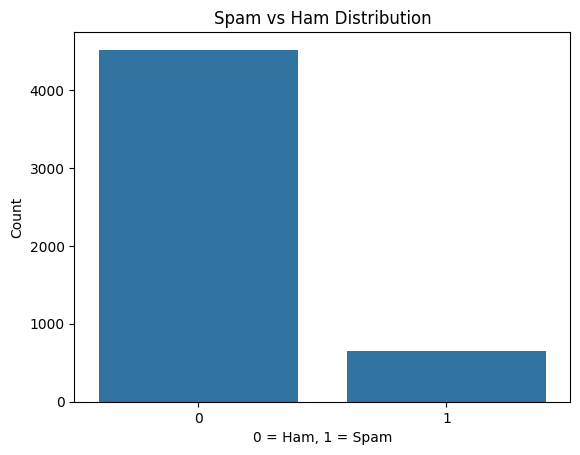

In [13]:
plt.figure()
sns.countplot(x='target', data=df)
plt.title("Spam vs Ham Distribution")
plt.xlabel("0 = Ham, 1 = Spam")
plt.ylabel("Count")
plt.show()

In [14]:
df['num_characters'] = df['text'].apply(len)

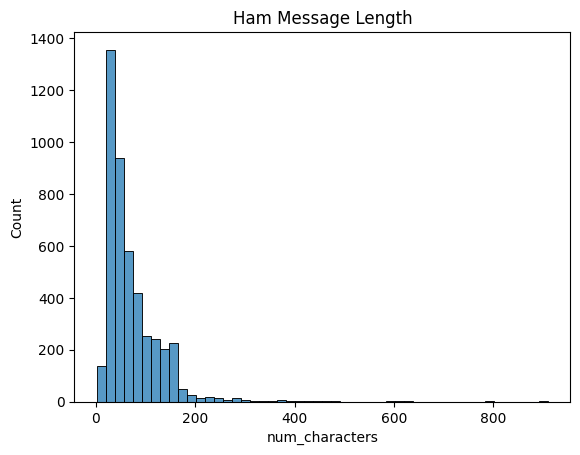

In [15]:
plt.figure()
sns.histplot(df[df['target'] == 0]['num_characters'], bins=50)
plt.title("Ham Message Length")
plt.show()

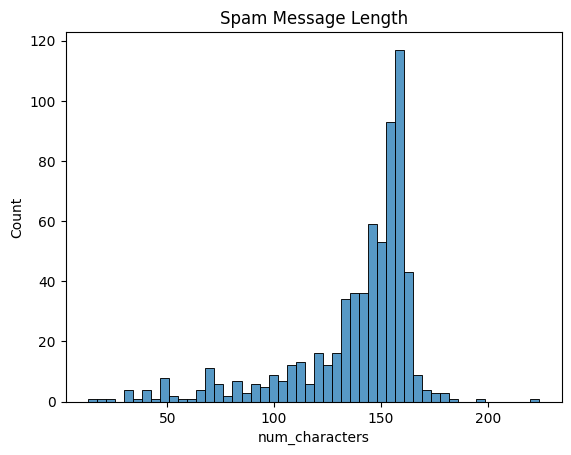

In [16]:

plt.figure()
sns.histplot(df[df['target'] == 1]['num_characters'], bins=50)
plt.title("Spam Message Length")
plt.show()


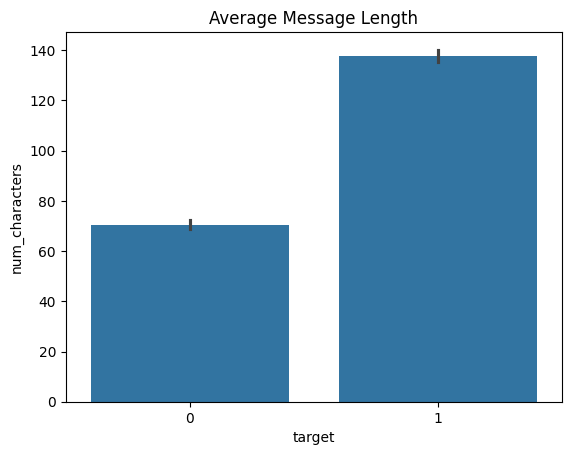

In [17]:

plt.figure()
sns.barplot(x='target', y='num_characters', data=df)
plt.title("Average Message Length")
plt.show()


In [18]:
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # Remove non-alphanumeric
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # Remove stopwords & punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


In [19]:
df['transformed_text'] = df['text'].apply(transform_text)

In [20]:
from wordcloud import WordCloud

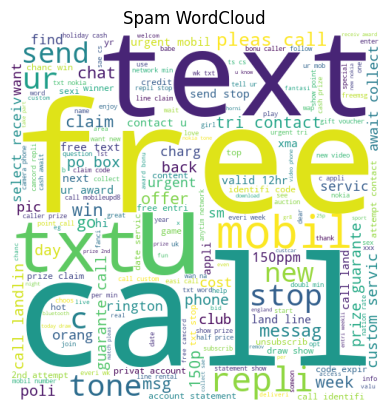

In [21]:
spam_wc = WordCloud(width=500, height=500, background_color='white')
spam_words = spam_wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

plt.figure()
plt.imshow(spam_words)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()


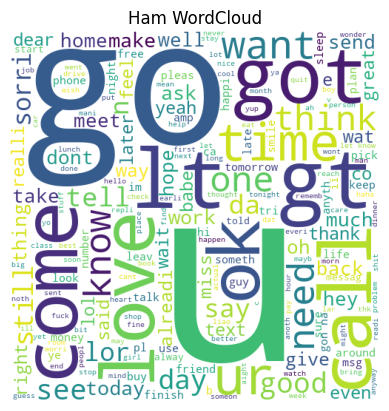

In [22]:
ham_wc = WordCloud(width=500, height=500, background_color='white')
ham_words = ham_wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure()
plt.imshow(ham_words)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()

In [23]:
tfidf = TfidfVectorizer(max_features=3000)


In [24]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
Y = df['target'].values

In [25]:

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [26]:

model = MultinomialNB()
model.fit(X_train, Y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:

Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))


Accuracy: 0.9709864603481625
Precision: 1.0


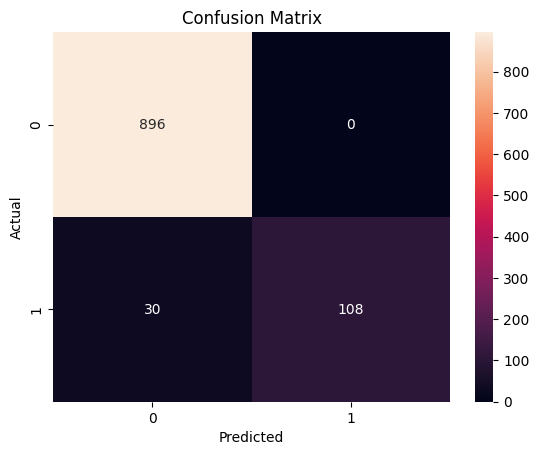

In [28]:
cm = confusion_matrix(Y_test, Y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))

print("Model & Vectorizer saved successfully!")


Model & Vectorizer saved successfully!
